<a href="https://www.kaggle.com/code/lalit7881/india-global-migration-eda-85?scriptVersionId=336277656" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aryanmdev/india-global-migration-dataset/indian_overseas_migration_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aryanmdev/india-global-migration-dataset/indian_overseas_migration_dataset.csv")

In [3]:
df.head()

,Year,Destination_Country,Region,Column_Name,Value,Data_Type,Source_Name,Source_URL,Notes
0,2000,USA,North America,Total_Indian_Migrants,"1,005,000",real,UN DESA International Migrant Stock,https://www.un.org/development/desa/pd/content...,Approx 1M Indian-born in USA ca. 2000 (Gibson ...
1,2000,USA,North America,Permanent_Migrants,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
2,2000,USA,North America,Temporary_Workers,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
3,2000,USA,North America,Students,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
4,2000,USA,North America,Remittance_USD_Billion,12.88,real,World Bank World Development Indicators,https://data.worldbank.org/indicator/BX.TRF.PW...,"Total India inflows, NOT disaggregated by sour..."


In [4]:
df.tail()

,Year,Destination_Country,Region,Column_Name,Value,Data_Type,Source_Name,Source_URL,Notes
1318,2026,Singapore,Asia,Temporary_Workers,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
1319,2026,Singapore,Asia,Students,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
1320,2026,Singapore,Asia,Remittance_USD_Billion,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
1321,2026,Singapore,Asia,Unemployment_India,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell
1322,2026,Singapore,Asia,GDP_India,NOT AVAILABLE,real,NaN,NaN,No publicly sourced figure found for this cell


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year                 1323 non-null   int64 
 1   Destination_Country  1323 non-null   object
 2   Region               1323 non-null   object
 3   Column_Name          1323 non-null   object
 4   Value                1323 non-null   object
 5   Data_Type            1323 non-null   object
 6   Source_Name          620 non-null    object
 7   Source_URL           620 non-null    object
 8   Notes                1278 non-null   object
dtypes: int64(1), object(8)
memory usage: 93.2+ KB


In [6]:
df.describe()

,Year
count,1323.000000
mean,2013.000000
std,7.791826
min,2000.000000
25%,2006.000000
50%,2013.000000
75%,2020.000000
max,2026.000000


In [7]:
df.isnull()

,Year,Destination_Country,Region,Column_Name,Value,Data_Type,Source_Name,Source_URL,Notes
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,True,True,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1318,False,False,False,False,False,False,True,True,False
1319,False,False,False,False,False,False,True,True,False
1320,False,False,False,False,False,False,True,True,False
1321,False,False,False,False,False,False,True,True,False


In [8]:
df.isnull().sum()

Year                     0
Destination_Country      0
Region                   0
Column_Name              0
Value                    0
Data_Type                0
Source_Name            703
Source_URL             703
Notes                   45
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Year', 'Destination_Country', 'Region', 'Column_Name', 'Value',
       'Data_Type', 'Source_Name', 'Source_URL', 'Notes'],
      dtype='object')

In [11]:
df.nunique()

Year                    27
Destination_Country      7
Region                   5
Column_Name              7
Value                  152
Data_Type                1
Source_Name             46
Source_URL              19
Notes                   34
dtype: int64

## EDA

In [12]:
# Convert Year to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Convert Value to numeric
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

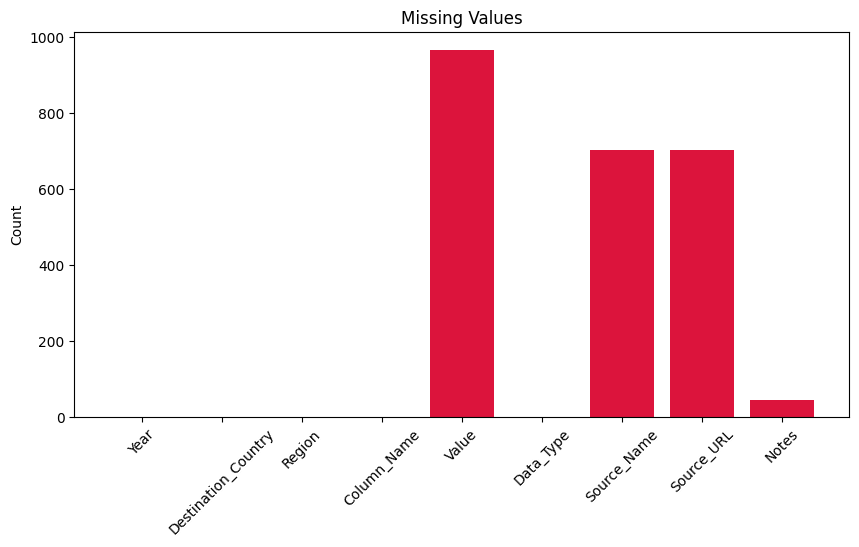

In [13]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing.values, color='crimson')
plt.xticks(rotation=45)
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

In [14]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1323 non-null   int64  
 1   Destination_Country  1323 non-null   object 
 2   Region               1323 non-null   object 
 3   Column_Name          1323 non-null   object 
 4   Value                357 non-null    float64
 5   Data_Type            1323 non-null   object 
 6   Source_Name          620 non-null    object 
 7   Source_URL           620 non-null    object 
 8   Notes                1278 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 93.2+ KB
None
               Year Destination_Country         Region            Column_Name  \
count   1323.000000                1323           1323                   1323   
unique          NaN                   7              5                      7   
top             NaN              

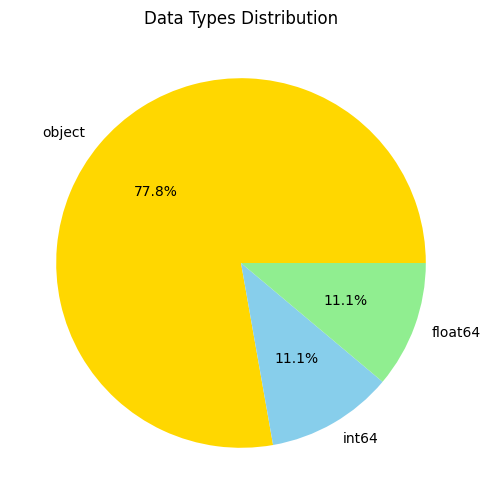

In [15]:
dtype_counts = df.dtypes.value_counts()

plt.figure(figsize=(6,6))
plt.pie(dtype_counts.values,
        labels=dtype_counts.index.astype(str),
        autopct='%1.1f%%',
        colors=['gold','skyblue','lightgreen'])
plt.title("Data Types Distribution")
plt.show()

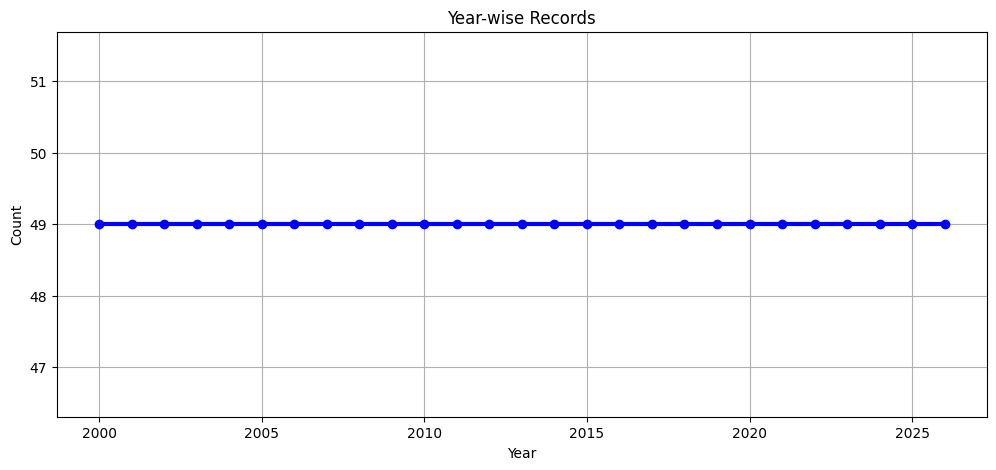

In [16]:
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index,
         year_counts.values,
         marker='o',
         color='blue',
         linewidth=3)

plt.title("Year-wise Records")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

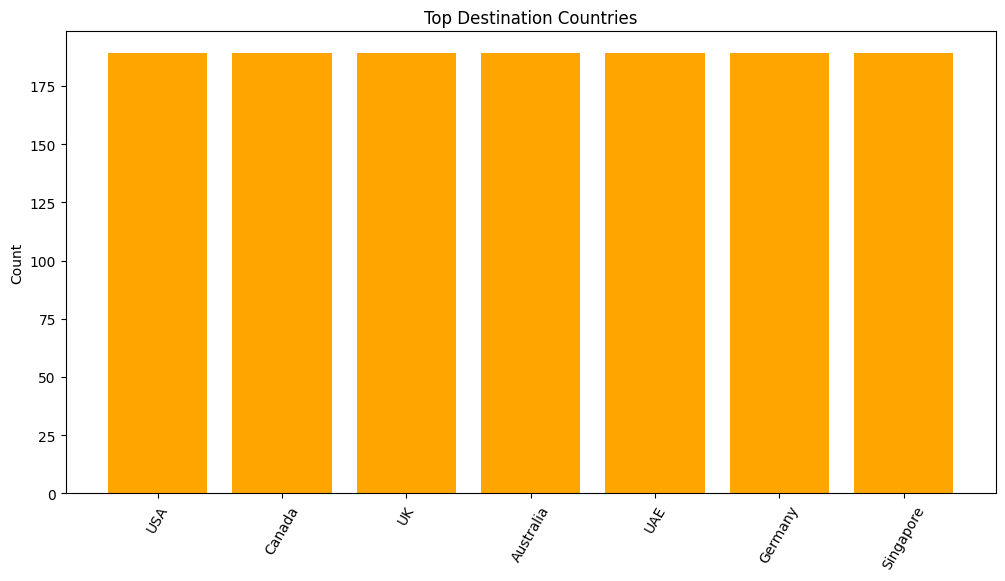

In [17]:
country = df['Destination_Country'].value_counts().head(15)

plt.figure(figsize=(12,6))
plt.bar(country.index,
        country.values,
        color='orange')

plt.xticks(rotation=60)
plt.title("Top Destination Countries")
plt.ylabel("Count")
plt.show()

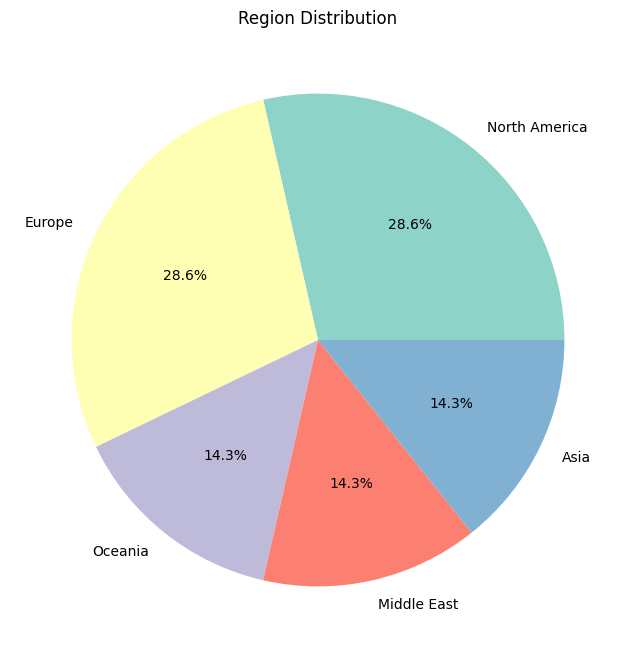

In [18]:
region = df['Region'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(region.values,
        labels=region.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set3.colors)

plt.title("Region Distribution")
plt.show()

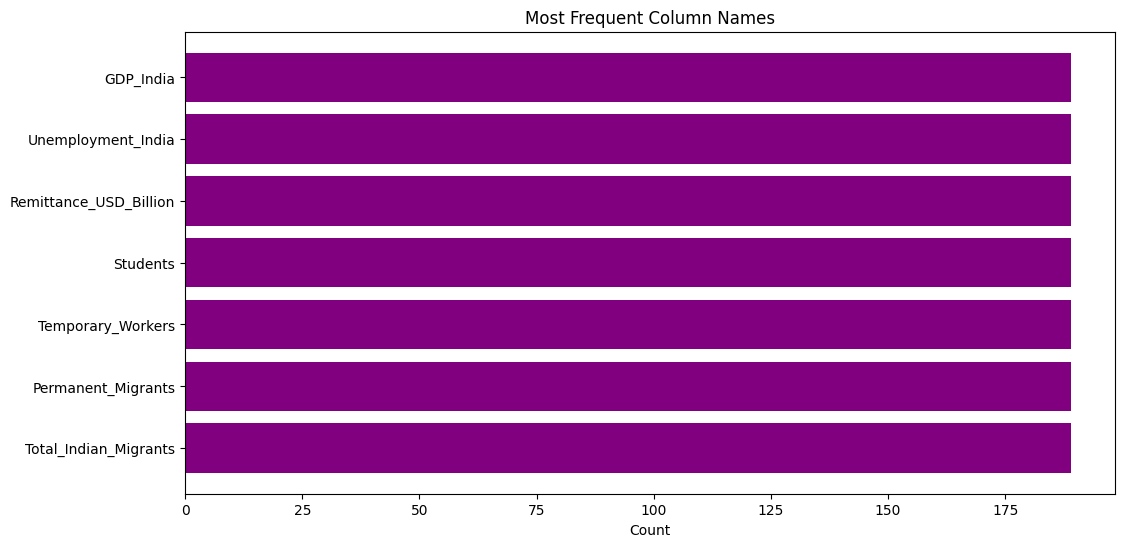

In [19]:
column_data = df['Column_Name'].value_counts().head(15)

plt.figure(figsize=(12,6))
plt.barh(column_data.index,
         column_data.values,
         color='purple')

plt.title("Most Frequent Column Names")
plt.xlabel("Count")
plt.show()

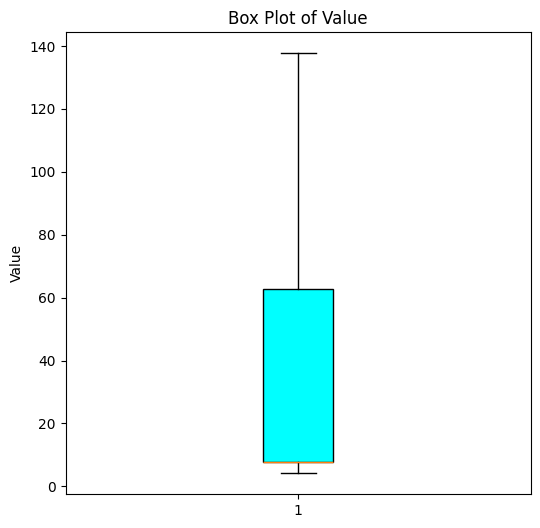

In [20]:
plt.figure(figsize=(6,6))
plt.boxplot(df['Value'].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor='cyan'))

plt.title("Box Plot of Value")
plt.ylabel("Value")
plt.show()

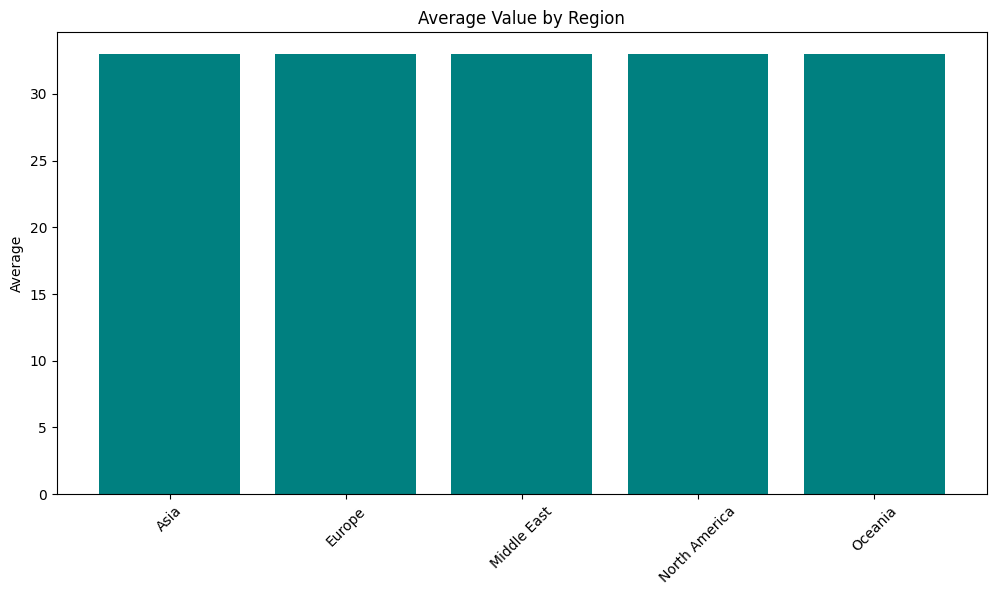

In [21]:
avg = df.groupby('Region')['Value'].mean().sort_values()

plt.figure(figsize=(12,6))
plt.bar(avg.index,
        avg.values,
        color='teal')

plt.xticks(rotation=45)
plt.title("Average Value by Region")
plt.ylabel("Average")
plt.show()

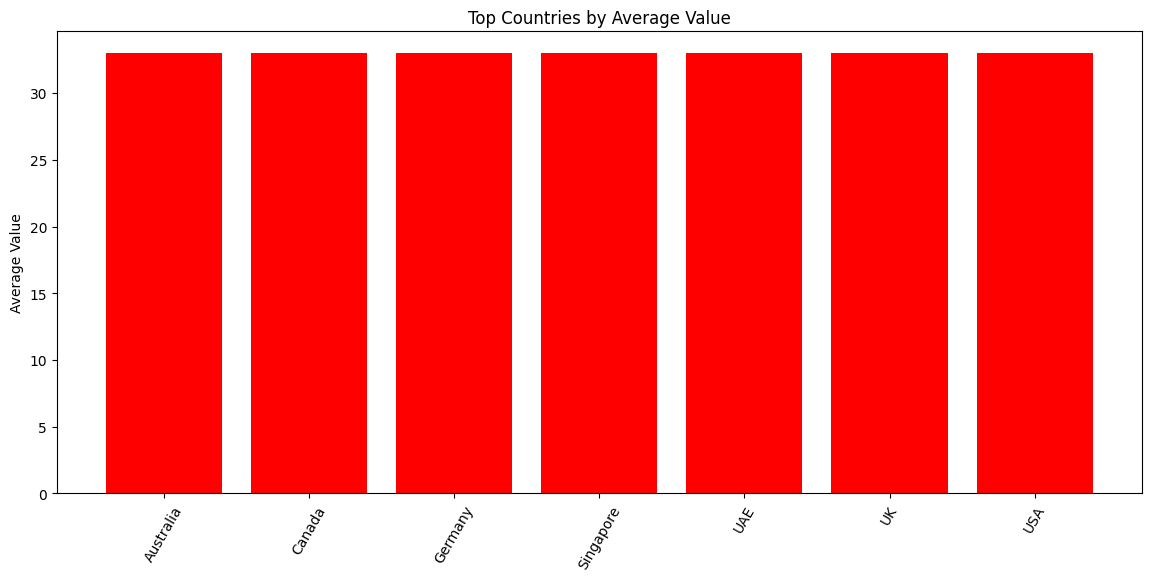

In [22]:
country_avg = df.groupby('Destination_Country')['Value'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,6))
plt.bar(country_avg.index,
        country_avg.values,
        color='red')

plt.xticks(rotation=60)
plt.title("Top Countries by Average Value")
plt.ylabel("Average Value")
plt.show()

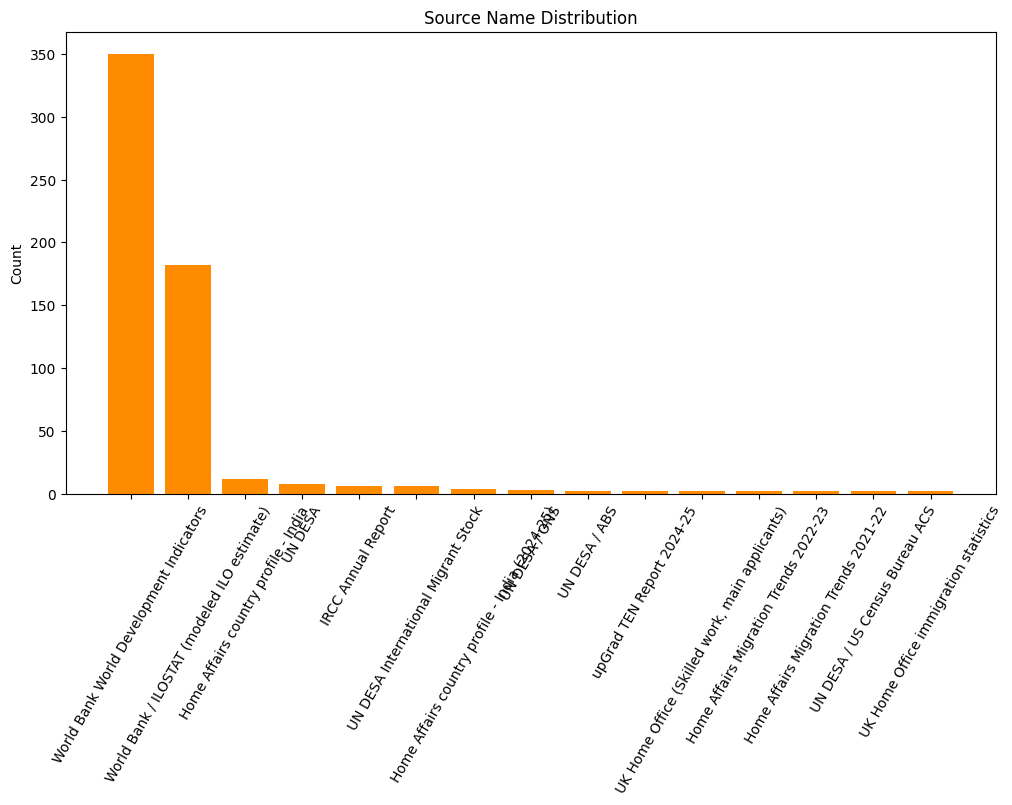

In [23]:
source = df['Source_Name'].value_counts().head(15)

plt.figure(figsize=(12,6))
plt.bar(source.index,
        source.values,
        color='darkorange')

plt.xticks(rotation=60)
plt.title("Source Name Distribution")
plt.ylabel("Count")
plt.show()

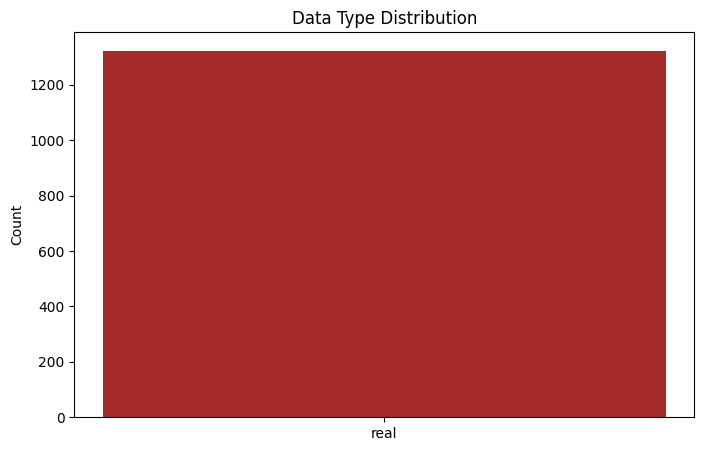

In [24]:
datatype = df['Data_Type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(datatype.index,
        datatype.values,
        color='brown')

plt.title("Data Type Distribution")
plt.ylabel("Count")
plt.show()

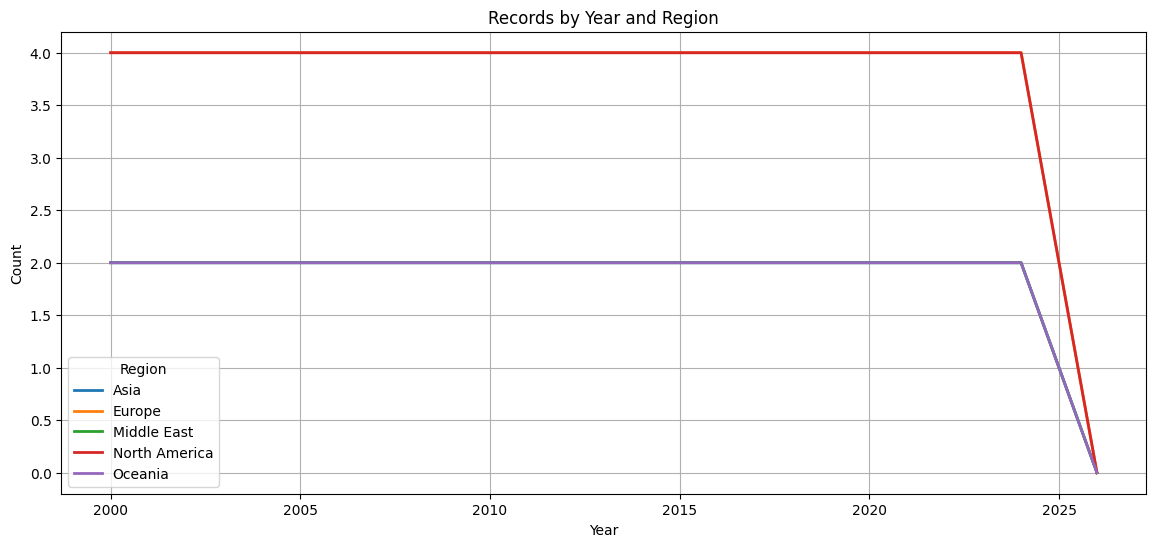

In [25]:
pivot = df.pivot_table(index='Year',
                       columns='Region',
                       values='Value',
                       aggfunc='count')

pivot.plot(figsize=(14,6),
           linewidth=2)

plt.title("Records by Year and Region")
plt.ylabel("Count")
plt.grid(True)
plt.show()

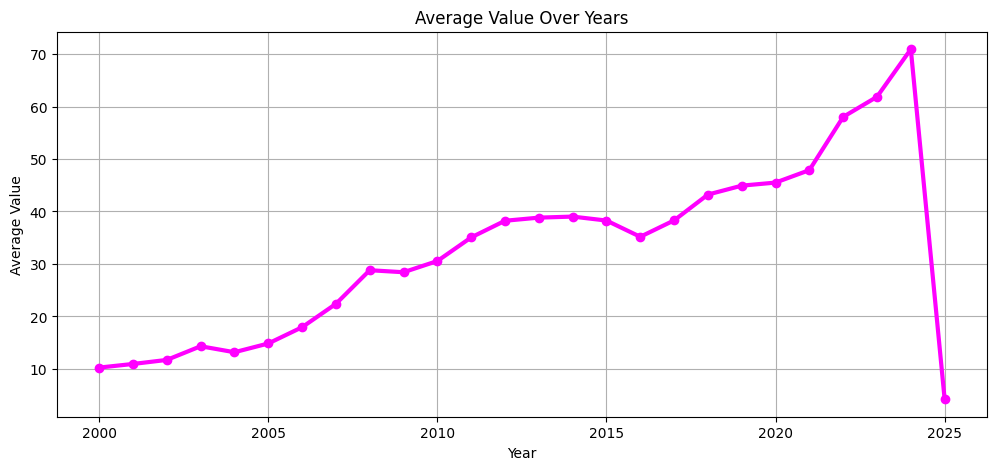

In [26]:
year_avg = df.groupby('Year')['Value'].mean()

plt.figure(figsize=(12,5))
plt.plot(year_avg.index,
         year_avg.values,
         marker='o',
         color='magenta',
         linewidth=3)

plt.title("Average Value Over Years")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()

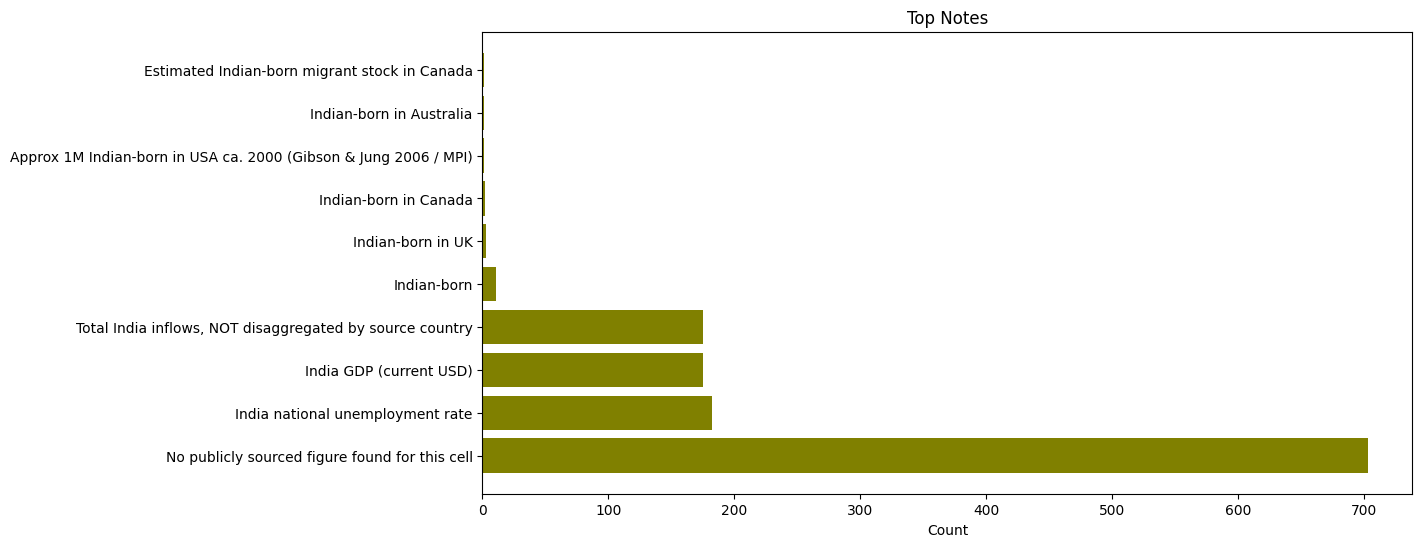

In [27]:
notes = df['Notes'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(notes.index,
         notes.values,
         color='olive')

plt.title("Top Notes")
plt.xlabel("Count")
plt.show()

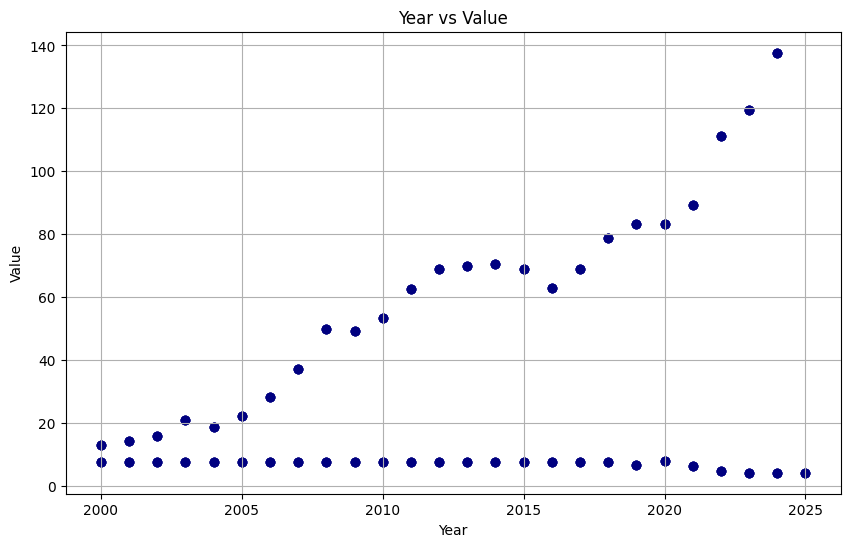

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(df['Year'],
            df['Value'],
            color='navy',
            alpha=0.6)

plt.title("Year vs Value")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True)
plt.show()

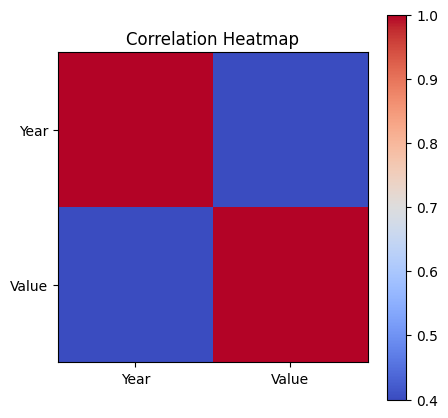

In [29]:
corr = df[['Year','Value']].corr()

plt.figure(figsize=(5,5))
plt.imshow(corr,
           cmap='coolwarm')

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

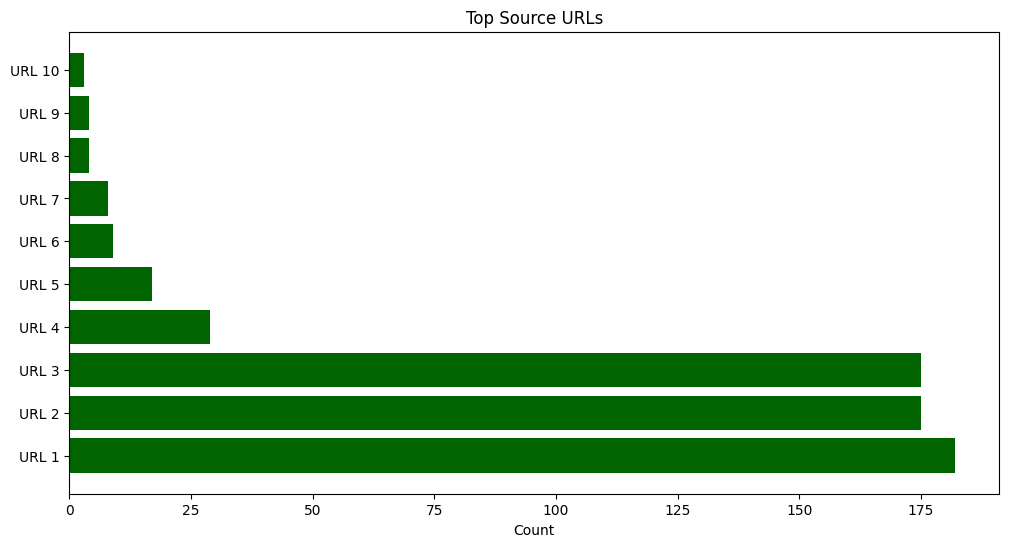

In [30]:
urls = df['Source_URL'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(range(len(urls)),
         urls.values,
         color='darkgreen')

plt.yticks(range(len(urls)), [f"URL {i+1}" for i in range(len(urls))])
plt.title("Top Source URLs")
plt.xlabel("Count")
plt.show()

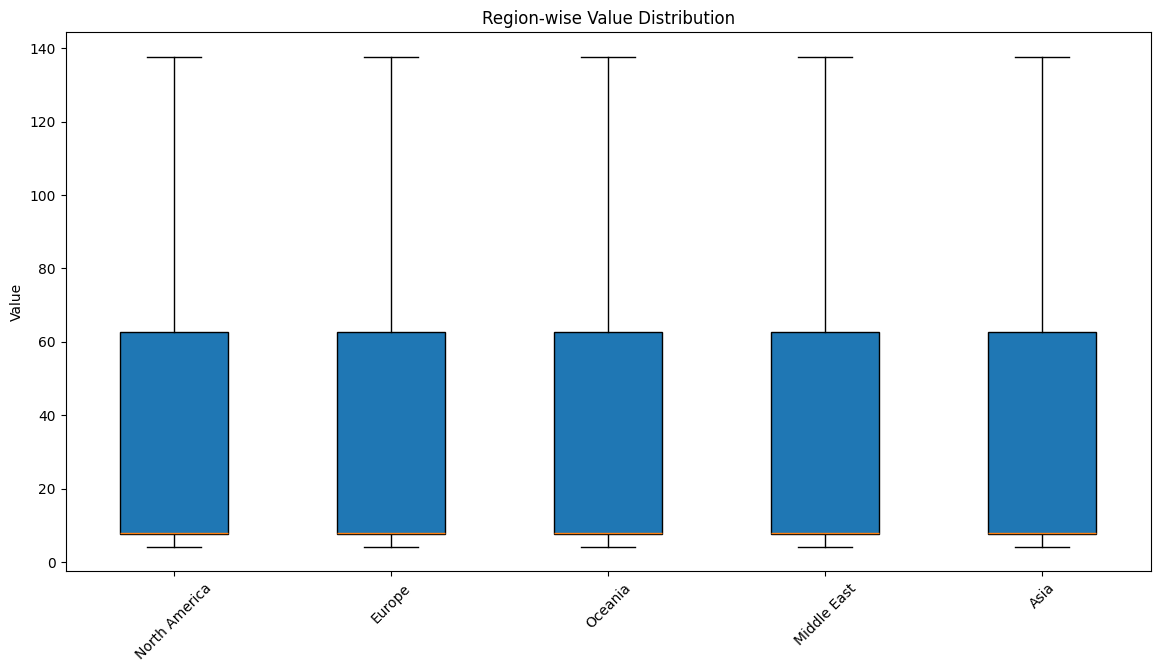

In [31]:
regions = df['Region'].dropna().unique()

plt.figure(figsize=(14,7))

data = [df[df['Region']==r]['Value'].dropna() for r in regions]

plt.boxplot(data,
            labels=regions,
            patch_artist=True)

plt.xticks(rotation=45)
plt.title("Region-wise Value Distribution")
plt.ylabel("Value")
plt.show()

## Feature engineering

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [33]:
print(df.info())

print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1323 non-null   int64  
 1   Destination_Country  1323 non-null   object 
 2   Region               1323 non-null   object 
 3   Column_Name          1323 non-null   object 
 4   Value                357 non-null    float64
 5   Data_Type            1323 non-null   object 
 6   Source_Name          620 non-null    object 
 7   Source_URL           620 non-null    object 
 8   Notes                1278 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 93.2+ KB
None
               Year Destination_Country         Region            Column_Name  \
count   1323.000000                1323           1323                   1323   
unique          NaN                   7              5                      7   
top             NaN              

In [34]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

In [35]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df.fillna(0, inplace=True)

In [36]:
encoder = LabelEncoder()

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   Year  Destination_Country  Region  Column_Name  Value  Data_Type  \
0  2000                    6       3            5   7.86          0   
1  2000                    6       3            1   7.86          0   
2  2000                    6       3            4   7.86          0   
3  2000                    6       3            3   7.86          0   
4  2000                    6       3            2  12.88          0   

   Source_Name  Source_URL  Notes  
0           41          17      9  
1           44           2     29  
2           44           2     29  
3           44           2     29  
4           44           0     31  


In [37]:
X = df.drop("Value", axis=1)

y = df["Value"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(1058, 8)
(265, 8)


In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [40]:
models = {

    "Linear Regression":LinearRegression(),

    "Decision Tree":DecisionTreeRegressor(random_state=42),

    "Random Forest":RandomForestRegressor(random_state=42),

    "Gradient Boosting":GradientBoostingRegressor(random_state=42),

    "Extra Trees":ExtraTreesRegressor(random_state=42),

    "KNN":KNeighborsRegressor(),

    "SVR":SVR(),

    "XGBoost":XGBRegressor(random_state=42),

    "LightGBM":LGBMRegressor(random_state=42)

}

In [41]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    results.append([

        name,
        mae,
        rmse,
        r2

    ])

results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

print(results.sort_values("R2 Score", ascending=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 99
[LightGBM] [Info] Number of data points in the train set: 1058, number of used features: 7
[LightGBM] [Info] Start training from score 14.631976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [42]:
best = results.sort_values(

    "R2 Score",

    ascending=False

)

print(best)

               Model           MAE          RMSE  R2 Score
1      Decision Tree  1.152286e-14  1.348955e-14  1.000000
7            XGBoost  3.949137e-04  8.607873e-04  1.000000
2      Random Forest  1.493585e-02  5.471169e-02  0.999994
3  Gradient Boosting  5.146895e-02  1.037256e-01  0.999978
4        Extra Trees  3.010717e-02  2.821585e-01  0.999837
8           LightGBM  4.739335e-01  1.754306e+00  0.993687
5                KNN  1.347675e+00  6.867356e+00  0.903262
0  Linear Regression  1.188844e+01  1.997384e+01  0.181649
6                SVR  5.943196e+00  2.064654e+01  0.125598


In [43]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

print(importance)

               Feature  Importance
6           Source_URL    0.690564
0                 Year    0.309116
3          Column_Name    0.000195
7                Notes    0.000047
5          Source_Name    0.000042
2               Region    0.000026
1  Destination_Country    0.000009
4            Data_Type    0.000000


In [44]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42)

score = cross_val_score(

    rf,

    X,

    y,

    cv=5,

    scoring="r2"

)

print("Scores:", score)

print("Average:", score.mean())

Scores: [0.51752192 0.92610621 0.95799474 0.98679209 0.90422653]
Average: 0.8585282996296326


## Thank you..pls upvote!!!!!!!!!!!!!